# Correspondence collapse and peak-latency shift

In [1]:
import warnings
warnings.filterwarnings("ignore")

import sys, os
sys.path.insert(0, os.path.abspath('..'))  # repo root, so `import src...` works

import numpy as np
import pandas as pd
from itertools import combinations

import matplotlib.pyplot as plt
from matplotlib import rcParams
import matplotlib.cm as cm

from scipy import signal, stats
from scipy.optimize import curve_fit

from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline

from IPython.display import display, Image

from src import config as cfg
from src import ecog_cnn as ec
from src.io_utils import save_fig, save_cache, load_cache, get_device

rcParams['figure.figsize'] = [14, 4]
rcParams['font.size'] = 12
rcParams['axes.spines.top'] = False
rcParams['axes.spines.right'] = False
rcParams['figure.autolayout'] = True

np.random.seed(cfg.RNG_SEED)


In [2]:
usable = cfg.usable
NOISE_LEVELS = cfg.NOISE_LEVELS
CONDITIONS = cfg.CONDITIONS
N_COND = cfg.N_COND
GROUP_NAMES = cfg.GROUP_NAMES
layer_names = cfg.layer_names
n_stim = cfg.n_stim
fs = cfg.fs
trange_d1 = cfg.trange_d1
baseline_d1 = cfg.baseline_d1
response_d1 = cfg.response_d1
trange_d2 = cfg.trange_d2
response_win = cfg.response_win
AUC_CRIT = cfg.AUC_CRIT
FACE_SEL_THRESH = cfg.FACE_SEL_THRESH
FACE_SEL_CRIT = cfg.FACE_SEL_CRIT
WIN_WIDTH, WIN_STEP, WIN_STARTS = cfg.WIN_WIDTH, cfg.WIN_STEP, cfg.WIN_STARTS
MIN_TRIALS_PER_CONDITION = cfg.MIN_TRIALS_PER_CONDITION
MIN_GROUP_SIZE = cfg.MIN_GROUP_SIZE
NOISE_HALFWIN = cfg.NOISE_HALFWIN
POP_HALFWIN = cfg.POP_HALFWIN
MIN_TRIALS_POP = cfg.MIN_TRIALS_POP

common_average_reference = ec.common_average_reference
broadband_power = ec.broadband_power
classify_region = ec.classify_region
compute_avg_magnitude = ec.compute_avg_magnitude
phase_scramble = ec.phase_scramble
crossnobis_1d = ec.crossnobis_1d
crossnobis_multivariate = ec.crossnobis_multivariate
cv_auc = ec.cv_auc
mean_ci95 = ec.mean_ci95
upper_tri = ec.upper_tri
compare_rdms = ec.compare_rdms
filter_outlier_trials = ec.filter_outlier_trials
partial_spearman = ec.partial_spearman
threshold_cross = ec.threshold_cross
corr_sigmoid = ec.corr_sigmoid
auc_sigmoid = ec.auc_sigmoid
fit_threshold = ec.fit_threshold
build_layer_rdm_crossnobis = ec.build_layer_rdm_crossnobis
build_layer_rdms_bootstrap_once = ec.build_layer_rdms_bootstrap_once
similarity_to_baseline = ec.similarity_to_baseline
build_comparison_df = ec.build_comparison_df
auc_face_vs_house = ec.auc_face_vs_house
perm = ec.category_major_perm()
reorder_rdm = ec.reorder_rdm
get_noise_window_indices = ec.get_noise_window_indices
subset_rdm = ec.subset_rdm

REG_COLORS = {'early_visual': 'tab:blue', 'ventral_temporal': 'tab:orange'}
group_colors = {'early_visual': 'tab:blue', 'ventral_temporal': 'tab:orange',
                'face_selective': 'tab:red', 'all': 'tab:gray'}
COND_NOISE = np.array([int(c.split('_')[1]) for c in CONDITIONS])
COND_ISFACE = np.array([c.startswith('face') for c in CONDITIONS]).astype(int)
layer_x = np.arange(len(layer_names))


In [3]:
_c = load_cache('05_cnn_representations')
cnn_layer_rdms_primary = _c['cnn_layer_rdms_primary']

_c = load_cache('06_ecog_cnn_correspondence')
q2_df = _c['q2_df']

_c = load_cache('07_per_electrode_correspondence')
elec_cache = _c['elec_cache']
elec = _c['elec']
face_sel_dat1 = _c['face_sel_dat1']


In [4]:
electrode_rdm = lambda s, ch: ec.electrode_rdm(elec_cache, s, ch)


## Correspondence collapse: at what noise does brain<->CNN RSA itself break down?

The sections above ask "when does the *decision* (face vs. house) fail?"
This section asks a different question: "when does the *representation*
stop resembling the CNN's?" -- i.e. the noise level where the RSA
correlation between an electrode's (or group's) RDM and its matched CNN
layer's RDM decays toward zero. This is a separate axis from the AUC-based
thresholds above: a representation can keep supporting decoding while
drifting away from the CNN's geometry, or vice versa, so these numbers
are not expected to match the AUC-based theta values and should not be
merged with them.

Correspondence at each noise level is measured the same way as the `Q2`
section earlier (30%-wide sliding noise windows, Spearman correlation
between RDMs), then a decay curve `r(n) = r0 / (1 + exp((n-theta)/w))` is
fit to extract a collapse point `theta_corr` and steepness.


PART A: 101 electrodes tested; 100 produced a usable decay fit (peak r > 0.05)
  early_visual: median theta_corr = 31.4% (n=24)
  ventral_temporal: median theta_corr = 35.0% (n=76)
  face-selective (dat1): median theta_corr = 31.4% (n=28)


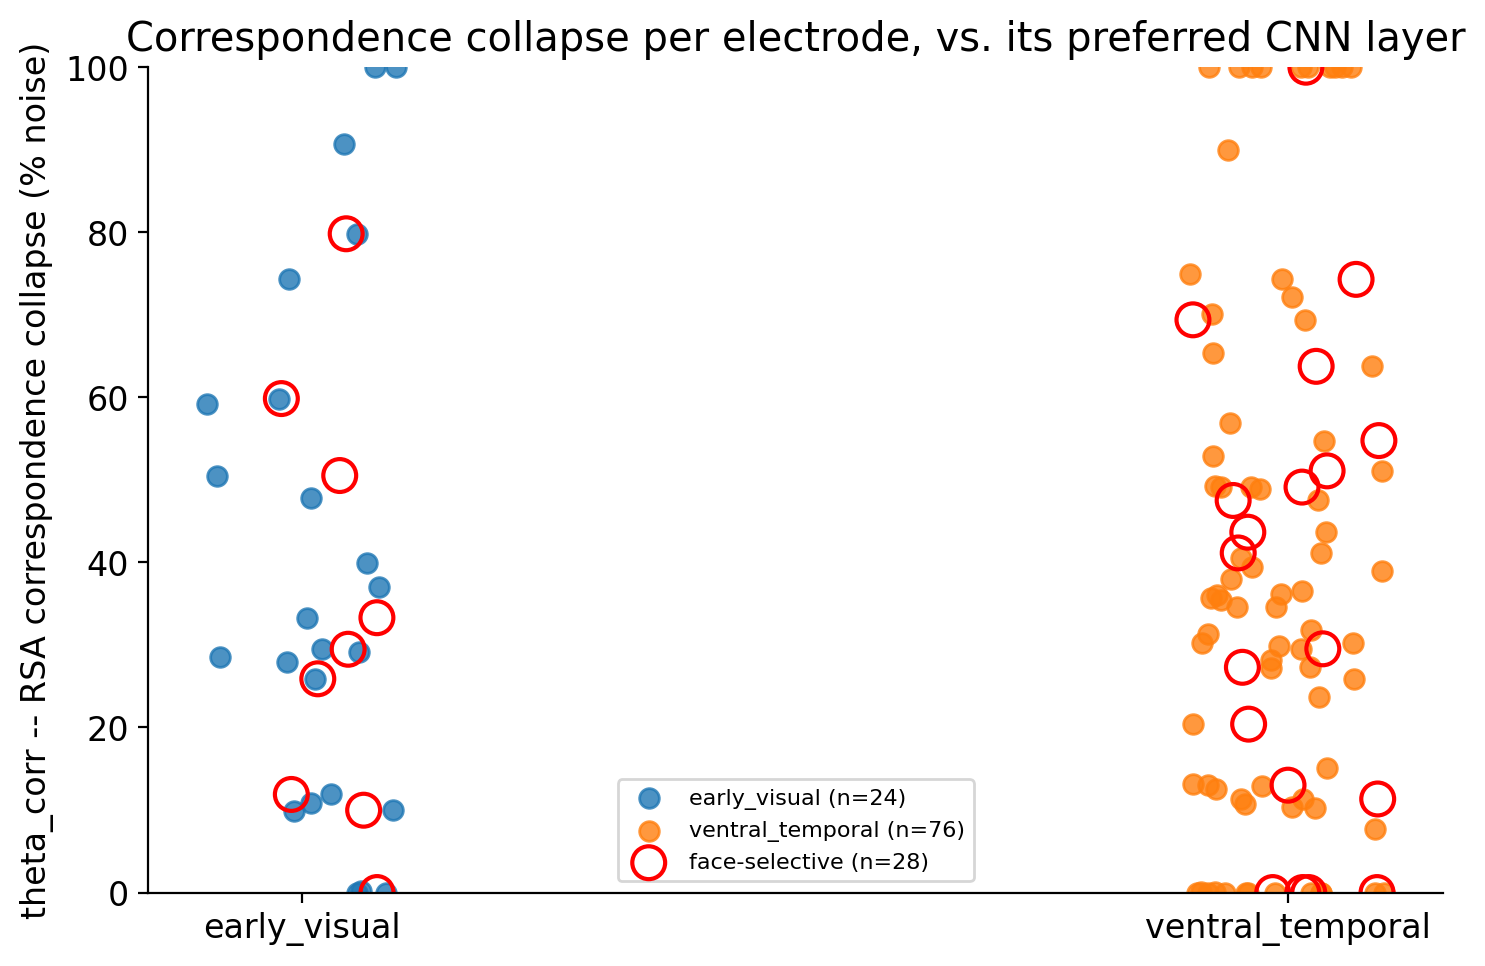

In [5]:
# @title Correspondence collapse -- Part A: per electrode vs. its preferred CNN layer

NOISE_W_CORR, NOISE_STEP_CORR = 30, 10
BAND_CENTERS = np.arange(15, 101, NOISE_STEP_CORR)
MIN_R_CLEAN = 0.05   # if correspondence is already ~0 at low noise, there is nothing to collapse

fit_corr_threshold = lambda centers, curve: ec.fit_corr_threshold(centers, curve, min_r_clean=MIN_R_CLEAN)

corr_rows = []
for _, row in elec.iterrows():
    s, ch = int(row['subject']), int(row['channel'])
    R = electrode_rdm(s, ch)
    if R is None or not np.isfinite(row['d_partial']):
        continue
    pref_layer = layer_names[int(round(np.clip(row['d_partial'], 0, len(layer_names)-1)))]
    cnn_rdm = cnn_layer_rdms_primary[pref_layer]
    r_curve = np.full(len(BAND_CENTERS), np.nan)
    for k, center in enumerate(BAND_CENTERS):
        idx, levels = get_noise_window_indices(center, NOISE_W_CORR)
        r_val, p_val, n_val = compare_rdms(subset_rdm(R, idx), subset_rdm(cnn_rdm, idx))
        r_curve[k] = r_val
    theta_c, slope_c, r2_c = fit_corr_threshold(BAND_CENTERS, r_curve)
    corr_rows.append(dict(subject=s, channel=ch, region=row['region'], pref_layer=pref_layer,
                           theta_corr=theta_c, slope_corr=slope_c, fit_r2_corr=r2_c,
                           is_fs=face_sel_dat1.get((s, ch), False)))
    globals().setdefault('corr_curve_store', {})[(s, ch)] = r_curve

corr_df = pd.DataFrame(corr_rows)
n_fit = corr_df['theta_corr'].notna().sum()
print(f"PART A: {len(corr_df)} electrodes tested; {n_fit} produced a usable decay fit (peak r > {MIN_R_CLEAN})")
for reg in ['early_visual', 'ventral_temporal']:
    sub = corr_df[(corr_df['region'] == reg) & corr_df['theta_corr'].notna()]
    if len(sub):
        print(f"  {reg}: median theta_corr = {sub['theta_corr'].median():.1f}% (n={len(sub)})")
sub_fs = corr_df[corr_df['is_fs'] & corr_df['theta_corr'].notna()]
if len(sub_fs):
    print(f"  face-selective (dat1): median theta_corr = {sub_fs['theta_corr'].median():.1f}% (n={len(sub_fs)})")

fig, ax = plt.subplots(figsize=(7.5, 5))
for reg, c in REG_COLORS.items():
    g = corr_df[(corr_df['region'] == reg) & corr_df['theta_corr'].notna()]
    ax.scatter(np.full(len(g), 0 if reg == 'early_visual' else 1) + np.random.uniform(-.1, .1, len(g)),
              g['theta_corr'], color=c, s=50, alpha=.8, label=f'{reg} (n={len(g)})')
fs_g = corr_df[corr_df['is_fs'] & corr_df['theta_corr'].notna()]
ax.scatter(np.where(fs_g['region'] == 'early_visual', 0, 1) + np.random.uniform(-.1, .1, len(fs_g)),
          fs_g['theta_corr'], facecolors='none', edgecolors='red', s=140, linewidths=1.5,
          label=f'face-selective (n={len(fs_g)})')
ax.set_xticks([0, 1]); ax.set_xticklabels(['early_visual', 'ventral_temporal'])
ax.set_ylabel('theta_corr -- RSA correspondence collapse (% noise)'); ax.set_ylim(0, 100)
ax.legend(fontsize=8); ax.set_title('Correspondence collapse per electrode, vs. its preferred CNN layer')
plt.tight_layout(); display(Image(save_fig(fig, '09_correspondence_collapse_and_latency_fig01'))); plt.close(fig)


PART B: group x layer correspondence-collapse threshold (theta_corr, from the Q2 noise-window RSA curves):
layer             pool1  pool2  pool3  pool4  pool5   fc6   fc7
group                                                          
all                50.9   50.7   48.9   37.3   40.6  42.1  42.0
early_visual       49.9   48.4   47.3   41.6   42.5  42.8  43.0
face_selective     55.2   54.7   52.7   48.4   48.4  48.2  48.0
ventral_temporal   49.2   50.2   47.8   41.2   42.6  42.8  42.7


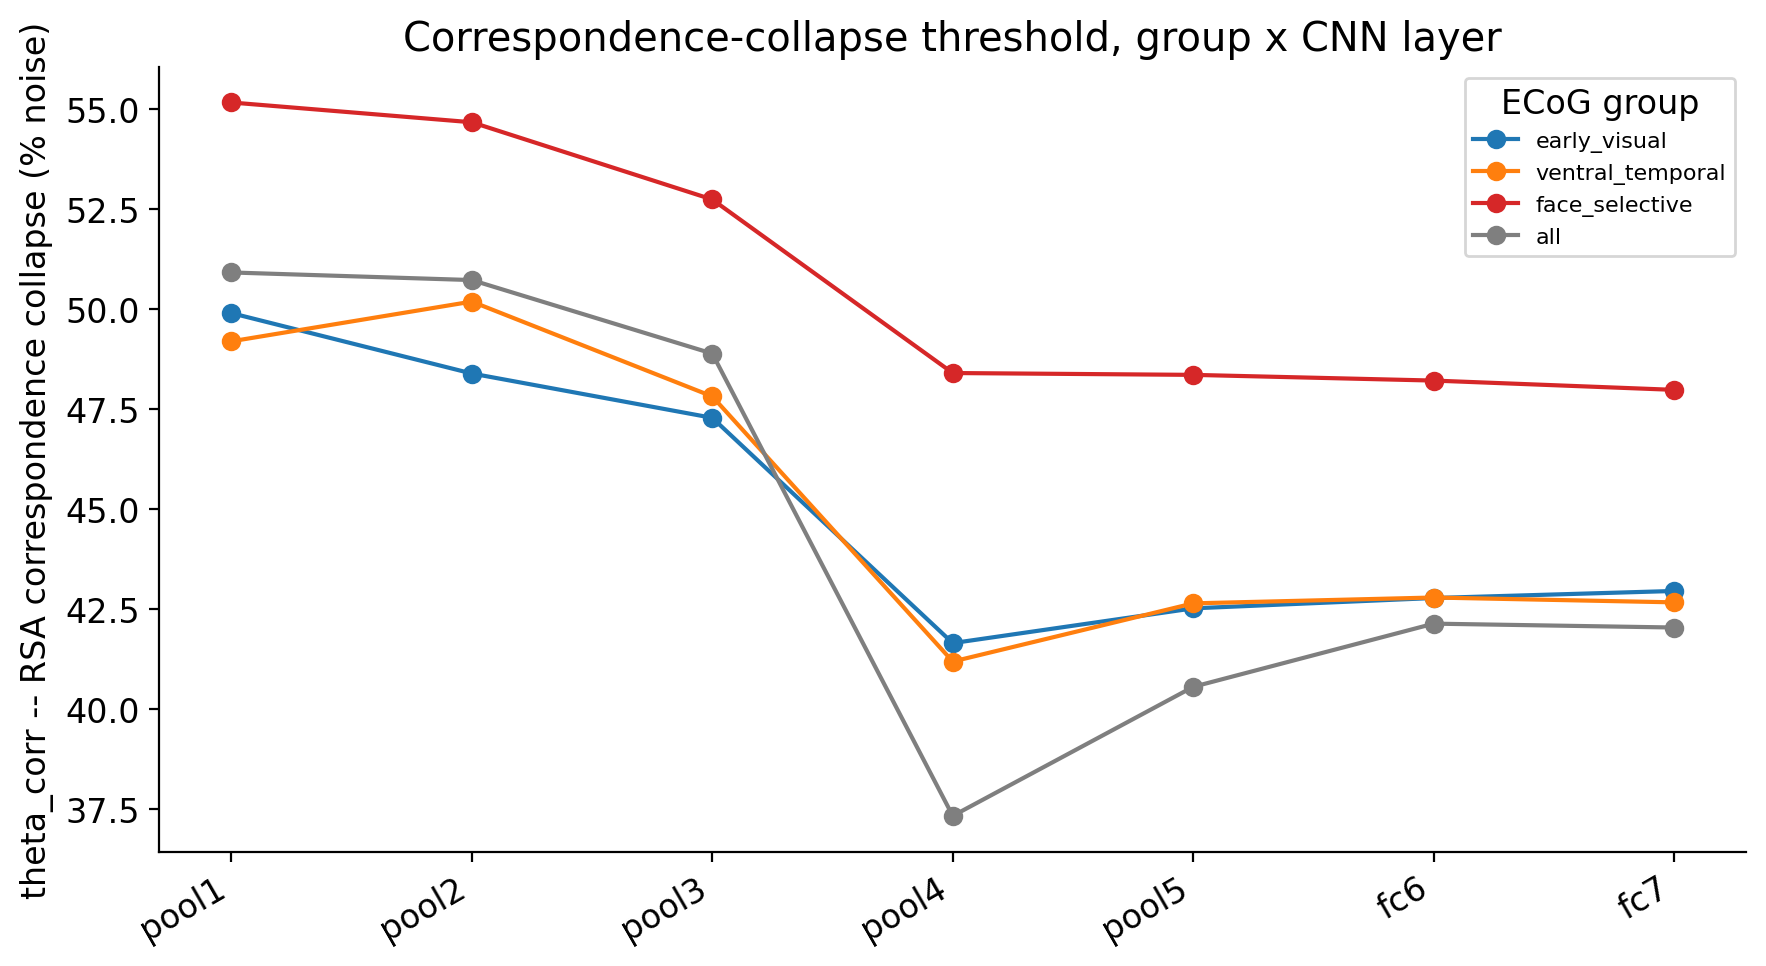

In [6]:
# @title Correspondence collapse -- Part B: each electrode group vs. each CNN layer (reuses the Q2 noise-window RSA)

q2_mean = q2_df.groupby(['group', 'layer', 'noise_center'], observed=True)['r'].mean().reset_index()
groupB_rows = []
for group_name in GROUP_NAMES:
    for L in layer_names:
        sub = q2_mean[(q2_mean['group'] == group_name) & (q2_mean['layer'] == L)].sort_values('noise_center')
        if len(sub) < 4:
            continue
        theta_b, slope_b, r2_b = fit_corr_threshold(sub['noise_center'].values, sub['r'].values)
        groupB_rows.append(dict(group=group_name, layer=L, theta_corr=theta_b, slope_corr=slope_b, fit_r2=r2_b))
groupB_df = pd.DataFrame(groupB_rows)
groupB_df['layer'] = pd.Categorical(groupB_df['layer'], categories=layer_names, ordered=True)

print("PART B: group x layer correspondence-collapse threshold (theta_corr, from the Q2 noise-window RSA curves):")
print(groupB_df.pivot(index='group', columns='layer', values='theta_corr').round(1))

fig, ax = plt.subplots(figsize=(9, 5))
for group_name in GROUP_NAMES:
    sub = groupB_df[groupB_df['group'] == group_name].dropna(subset=['theta_corr'])
    if len(sub) == 0:
        continue
    xs = [layer_names.index(L) for L in sub['layer']]
    ax.plot(xs, sub['theta_corr'], 'o-', color=group_colors.get(group_name, 'black'), label=group_name)
ax.set_xticks(range(len(layer_names))); ax.set_xticklabels(layer_names, rotation=30, ha='right')
ax.set_ylabel('theta_corr -- RSA correspondence collapse (% noise)')
ax.set_title('Correspondence-collapse threshold, group x CNN layer')
ax.legend(fontsize=8, title='ECoG group')
plt.tight_layout(); display(Image(save_fig(fig, '09_correspondence_collapse_and_latency_fig02'))); plt.close(fig)



Peak latency (ms) by region x noise band, median across electrodes:
noise_bin          0-25  25-50  50-75
region                               
early_visual      400.0  287.5  200.0
ventral_temporal  400.0  350.0  300.0


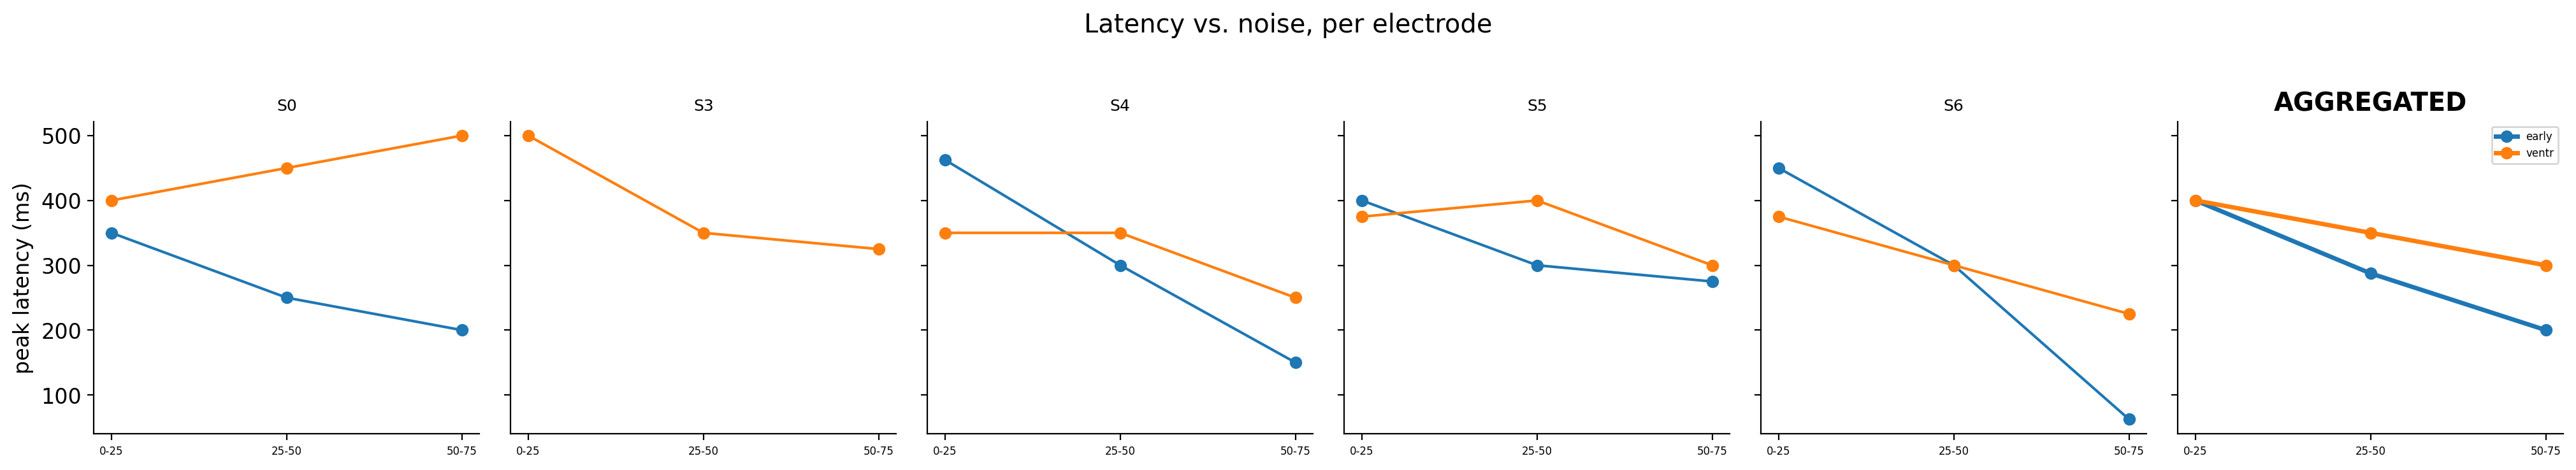

In [7]:
# @title Per-electrode peak-latency shift with noise (top-3 electrodes per region x subject)

H3_W, H3_STEP = 50, 25
H3_STARTS = np.arange(0, 551, H3_STEP)
NOISE_BINS = [(0,25),(25,50),(50,75)]
H3_LAYERS = ['pool1', 'pool5', 'fc7']

def rdm_win(s, ch, lo, hi, nlo, nhi):
    c = elec_cache[s]
    if ch not in c['good']:
        return None, []
    loc = np.where(c['good']==ch)[0][0]
    wm = (trange_d2 >= lo) & (trange_d2 < hi)
    x = c['epochs'][:, wm, loc].mean(1); x = (x-x.mean())/(x.std()+1e-9)
    keep = [i for i in range(N_COND) if nlo <= COND_NOISE[i] < nhi]
    idx = {i: np.where((c['noise']==COND_NOISE[i]) & (c['cat']==(2 if COND_ISFACE[i] else 1)))[0] for i in keep}
    k = len(keep); R = np.full((k,k), np.nan); np.fill_diagonal(R, 0)
    for a in range(k):
        for b in range(a+1, k):
            ia, ib = idx[keep[a]], idx[keep[b]]
            if len(ia) >= 4 and len(ib) >= 4:
                R[a,b] = R[b,a] = crossnobis_1d(x[ia], x[ib])
    return R, keep

h3 = []
for s in usable:
    for reg in ['early_visual', 'ventral_temporal']:
        tg = elec[(elec['subject']==s) & (elec['region']==reg)].nlargest(3, 'auc_clean')
        for _, e in tg.iterrows():
            ch = int(e['channel'])
            for nlo, nhi in NOISE_BINS:
                for st in H3_STARTS:
                    R, keep = rdm_win(s, ch, st, st+H3_W, nlo, nhi)
                    if R is None or len(keep) < 6:
                        continue
                    for L in H3_LAYERS:
                        a, b = upper_tri(R), upper_tri(cnn_layer_rdms_primary[L][np.ix_(keep,keep)])
                        m = np.isfinite(a) & np.isfinite(b)
                        if m.sum() >= 10:
                            h3.append(dict(subject=s, region=reg, channel=ch, layer=L,
                                            noise_bin=f'{nlo}-{nhi}', t=st+H3_W//2, r=stats.spearmanr(a[m],b[m])[0]))
h3_df = pd.DataFrame(h3)
if len(h3_df):
    pk = h3_df.dropna(subset=['r'])
    pk = pk.loc[pk.groupby(['subject','channel','layer','noise_bin'])['r'].idxmax()]
    print('Peak latency (ms) by region x noise band, median across electrodes:')
    print(pk.pivot_table(index='region', columns='noise_bin', values='t', aggfunc='median'))
    fig, axes = plt.subplots(1, len(usable)+1, figsize=(3.4*(len(usable)+1), 3.6), sharey=True)
    for ax, s in zip(axes[:-1], usable):
        sub = pk[pk['subject']==s]
        if len(sub)==0:
            ax.set_title(f'S{s}:-'); ax.axis('off'); continue
        for reg, c in REG_COLORS.items():
            g = sub[sub['region']==reg].groupby('noise_bin')['t'].median()
            if len(g):
                ax.plot(range(len(g)), g.values, 'o-', color=c, label=reg[:5])
        ax.set_xticks(range(len(NOISE_BINS))); ax.set_xticklabels([f'{a}-{b}' for a,b in NOISE_BINS], fontsize=6)
        ax.set_title(f'S{s}', fontsize=9)
    ax = axes[-1]
    for reg, c in REG_COLORS.items():
        g = pk[pk['region']==reg].groupby('noise_bin')['t'].median()
        if len(g):
            ax.plot(range(len(g)), g.values, 'o-', color=c, lw=2.5, label=reg[:5])
    ax.set_xticks(range(len(NOISE_BINS))); ax.set_xticklabels([f'{a}-{b}' for a,b in NOISE_BINS], fontsize=6)
    ax.set_title('AGGREGATED', fontweight='bold'); ax.legend(fontsize=6)
    axes[0].set_ylabel('peak latency (ms)')
    plt.suptitle('Latency vs. noise, per electrode', y=1.02)
    plt.tight_layout(); display(Image(save_fig(fig, '09_correspondence_collapse_and_latency_fig03'))); plt.close(fig)

